Josefina Yantén L.

# Análisis Exploratorio de Datos: Titanic

En esta actividad usaremos la base de datos de pasajeros del Titanic para practicar **análisis exploratorio de datos (EDA)**.

El objetivo no es hacer la mayor cantidad posible de gráficos, sino aprender a **usar los datos para responder preguntas**.

## Pregunta de investigación

> **¿Qué características de los pasajeros estaban asociadas con la supervivencia en el Titanic?**


## Librerías de visualización
### Matplotlib

Matplotlib tiene dos métodos para crear una figura, uno directo y otro enfocado a objetos. 
Algunos links de interés:

- Argumentos que reciben matplotlib: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
- Más opciones de gráficos en https://matplotlib.org/2.0.2/gallery.html
- Para una lista de colores disponibles en Matplotlib, https://matplotlib.org/stable/gallery/color/named_colors.html
- Explicación de plt y ax https://towardsdatascience.com/what-are-the-plt-and-ax-in-matplotlib-exactly-d2cf4bf164a9


### Seaborn
Proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos. A diferencia de Matplotlib, ésta no viene por defecto en Pandas. 
Galería de gráficos: https://seaborn.pydata.org/examples/index.html

Otro link útil para visualizaciones en Python: https://python-graph-gallery.com/


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("white")


## Carga de los datos

Cada fila de la base de datos corresponde a **un pasajero**.

Las principales características disponibles son:

- `Survived`: supervivencia, 0 = no, 1 = sí
- `Pclass`: clase del pasajero, 1 = primera, 2 = segunda, 3 = tercera
- `Sex`: sexo
- `Age`: edad
- `SibSp`: número de hermanos/as o cónyuges a bordo
- `Parch`: número de padres o hijos a bordo
- `Ticket`: identificador del pasaje
- `Fare`: tarifa pagada
- `Cabin`: cabina
- `Embarked`: puerto de embarque, C = Cherbourg, Q = Queenstown, S = Southampton


In [3]:
titanic = pd.read_csv("titanic_semana_02.csv")
titanic.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### **¿Cuáles variables son numéricas y cuáles son categóricas?**



- Correspondientes a variables numéricas se tienen: age, fare.
Correspondientes a variables categóricas se tienen: survived, sex, Pclass, name, Parch, SibSp, ticket, cabin, embarked.

# Parte 1: Comprender la muestra

## ¿Quiénes eran los pasajeros del Titanic?

Antes de estudiar la supervivencia, necesitamos comprender a quiénes representan los datos.

Preguntas iniciales:

- ¿Cuántos pasajeros hay?
- ¿Qué características contiene la base de datos?
- ¿Cómo se distribuyen por sexo y clase?
- ¿Qué edades aparecen?
- ¿Cuánto pagaron por sus pasajes?
- ¿Viajaban solos o acompañados?
- ¿Desde qué puerto embarcaron?

Revise la estructura general de la tabla: dimensión, columnas, estadística básica, etc.

### Ejemplo de gráfico: pasajeros por sexo

Para una característica categórica podemos comenzar contando cuántos pasajeros pertenecen a cada grupo.


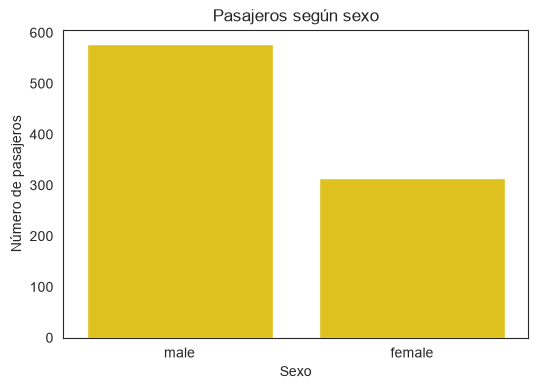

In [4]:
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Sex", color="gold")

plt.xlabel("Sexo")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según sexo")

plt.show()


### Ahora usted

**1. Grafique la cantidad de pasajeros según `Pclass`.**

- Qué clase contiene más pasajeros?
- La muestra está balanceada entre las tres clases?


- R: La clase 3 contiene mas pasajeros. Además al ver el gráfico es indudable que la muestra no está balanceada entre estas tres clases, ya que por ejemplo la clase 3 tiene casi 500 pasajeros, en cambio la primera clase tiene cerca de 200.

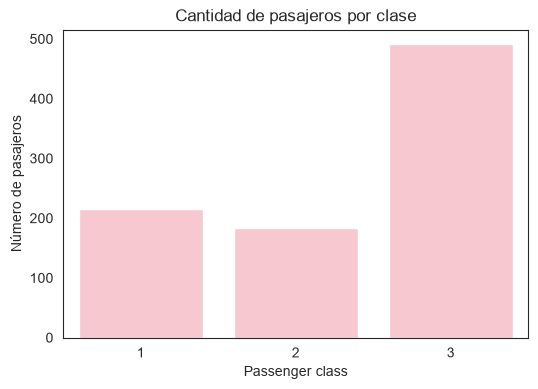

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Pclass", color="pink")

plt.xlabel("Passenger class")
plt.ylabel("Número de pasajeros")
plt.title("Cantidad de pasajeros por clase")

plt.show()


**2. Explore la distribución de `Age` con un histograma.**

Pruebe, por ejemplo, con 15, 30 y 50 bins.

- ¿Qué edades son más frecuentes?
- ¿La distribución parece simétrica?
- ¿El número de bins cambia su interpretación?


- R: Las edades más frecuentes se ve que están entre los 20 y los 30.
En este caso no se ve una distribución simetrica tipo "gaussiana".
Al cambiar el número de bins y cambia un poco la interpretación, ya que a mayor cantidad de bins, mayor cantidad de detalle entrega el gráfico. Por ejemplo, en el histograma con 15 bins se puede ver como que la edad más frecuente es justo alrededor de los 30 años, pero al aumentar la cantidad de bins se aprecia que en verdad esta mayor frecuencia se encuentra entre los 20 y 30 años.

Text(0.5, 1.0, '50 bins')

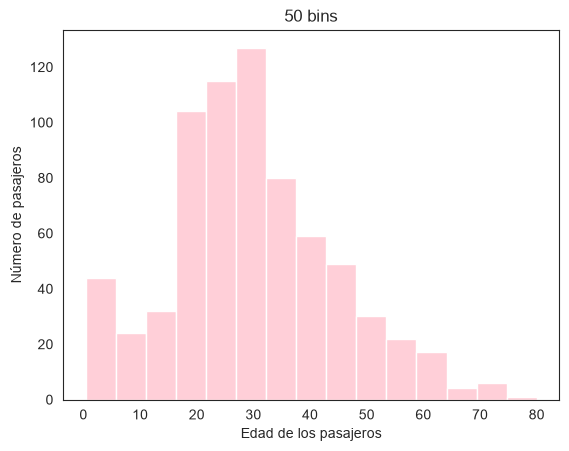

In [6]:
#Vemos que con esta función de seaborn podemos hacer de forma facil un histograma.
sns.histplot(data=titanic ,x="Age", bins=15, color="pink")
plt.xlabel("Edad de los pasajeros")
plt.ylabel("Número de pasajeros")
plt.title("50 bins")


- R: Pero es útil también poder ver histogramas con disttinta cantidad de bins para compararlos y ver cual de ellos es el que mejor se ajusta a lo que buscamos para analizar. Además con esto podemos ver de mejor forma si es que al cambiar la cantidad de bins la distibución cambia mucho o no.

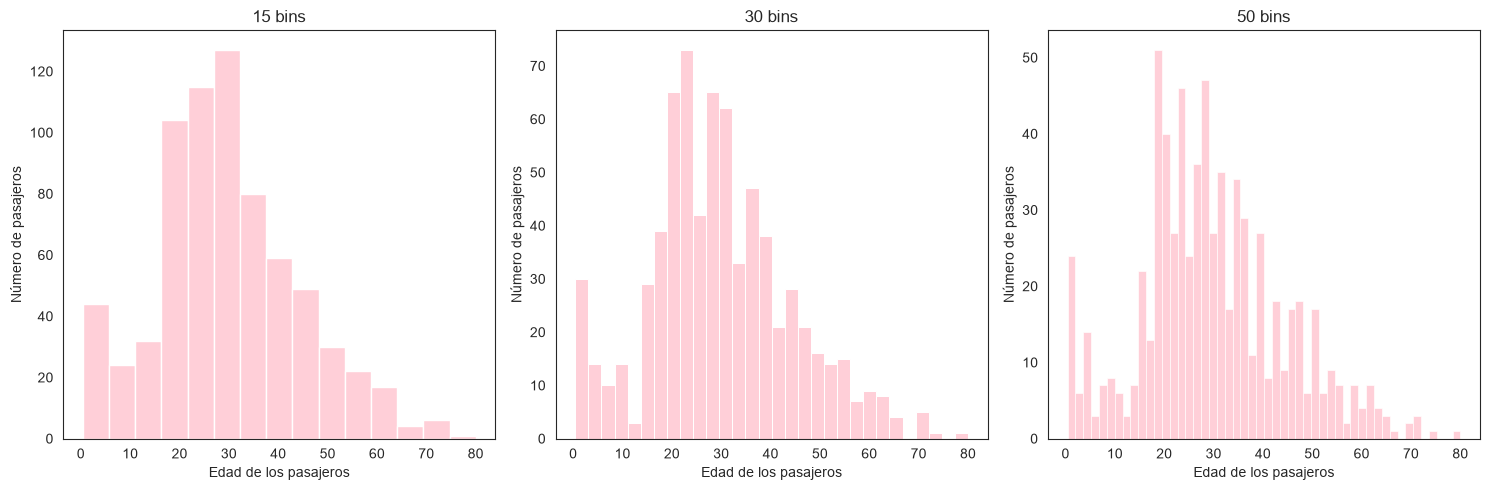

In [7]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
bins_valores = [15, 30, 50]

for i, b in enumerate(bins_valores):
    sns.histplot(data=titanic, x="Age", bins=b, color="pink", ax=axes[i])
    axes[i].set_xlabel("Edad de los pasajeros")
    axes[i].set_ylabel("Número de pasajeros")
    axes[i].set_title(f"{b} bins")
plt.tight_layout()
plt.show()

**3. Explore la distribución de `Fare`.**

Puede usar un histograma o un boxplot.

- ¿La distribución es simétrica?
- ¿Existen tarifas muy superiores al resto?
- ¿Qué podría significar esto?


- R: La distribución en este caso no es simétrica, basicamente se aprecia porque la mediana no está en el centro de las cajas.
Si, existen tarifas superiores al resto, claramente se ve que la primera clase es la que paga mayor valor, pero también es intenerate notar los outliers allí.
Esto se puede interpretar como que quizás se pagaba una tarifa base y luego relacionado a las comodidades y lujos que se quería tener, el monto de la tarifa iba aumentando.

<Axes: xlabel='Fare', ylabel='Pclass'>

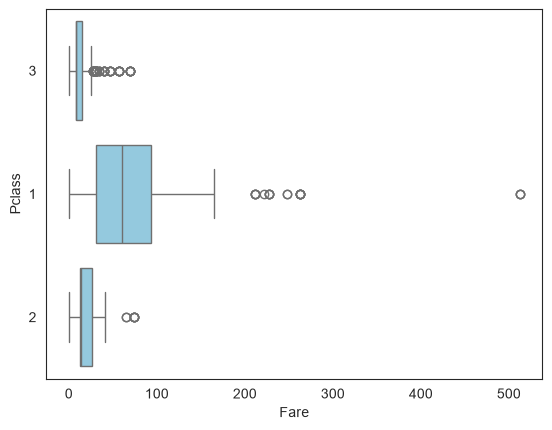

In [8]:
sns.boxplot(data=titanic, x="Fare", y=titanic["Pclass"].astype(str), color="skyblue")
#se agrega el .astype(str) para que se consideren los valores de Pclass como un string (ya que están siendo usados el 1,2 y 3 para definir una clase social)
#Además en este caso elegí hacer el boxplot de la variable fare pero diviendolo por clase para así obtener una mejor visualización de los datos.

# Parte 2: Calidad de los datos

## ¿Qué información falta y por qué podría importar?

Antes de interpretar cualquier patrón debemos revisar la calidad de los datos.

Nos interesa detectar:

- valores faltantes
- características con mucha información incompleta
- valores extremos o sospechosos
- decisiones de limpieza que puedan cambiar nuestras conclusiones


In [9]:
datos_faltantes = titanic.isnull().sum()
datos_faltantes


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Ejemplo de gráfico: valores faltantes

Podemos visualizar cuántos datos faltan en cada característica.


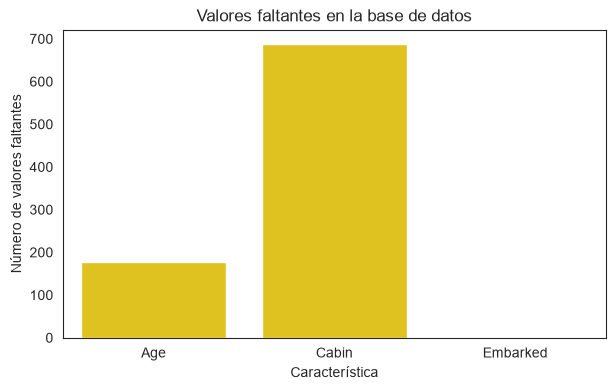

In [10]:
faltantes = datos_faltantes[datos_faltantes > 0]

plt.figure(figsize=(7,4))

sns.barplot(x=faltantes.index, y=faltantes.values, color='gold')

plt.xlabel("Característica")
plt.ylabel("Número de valores faltantes")
plt.title("Valores faltantes en la base de datos")

plt.show()


### Ahora usted

Observe especialmente `Age`, `Cabin` y `Embarked`.

**1. Compare la media y la mediana de `Age`.**

- Son similares?
- Es la media una buena representación de una edad típica?


- R: En el caso de lo obtenido abajo, la media y la mediana en este caso si son similares.
Considerando que la media representa el promedio (en este caso de edad), si sería una buena representación de una edad típica, ya que como la media y la mediana en este caso tiene valores similares, indica que existe una distribución equilibrada de los datos.

In [11]:
Media= titanic["Age"].mean()
Mediana= titanic["Age"].median()
Comparacion= Media/Mediana

print("La media y mediana de Age son", Media, "y", Mediana, "respectivamente")
print("La media de Age es", Comparacion, "más grande que la mediana")


La media y mediana de Age son 29.69911764705882 y 28.0 respectivamente
La media de Age es 1.0606827731092436 más grande que la mediana


**2. La edad tiene datos faltantes.**

- Le parece razonable reemplazar todas las edades faltantes por la media?
- Qué problema podría producir esa decisión en la distribución de edades?
- Qué otra estrategia consideraría?


- R: No me parece muy razonable reemplazar todas las edades faltantes por la media, porque son 177 datos. Aunque si se considera que la media no está muy lejana a la mediana en este caso no debería haber un mayor cambio respecto a ellas.

- Creo que el problema que podría surgir en este caso sería que la varianza si cambiaría considerablemente.

- Creo que en vez de usar la media general, trataría de dividir los datos faltates por ejemplo por clase y/o género en ella y ver cuál es la media en cada uno de esos casos. Al obtener eso, reemplazaría la media correspondiente a cada grupo para que sea un valor más específico.



**3. `Cabin` tiene una gran cantidad de valores faltantes.**

- Intentaría rellenarlos?
- Eliminaría la característica?
- Podría el hecho de conocer o no la cabina contener información por sí mismo?

No hay una única respuesta correcta: justifique su decisión.


- R: No intentaría rellenarlos porque no habría una forma de saber exactamente en qué cabina estaban esas personas, aunque si sabemos la clase en la que iba esa persona se podría tener un grupo posible, pero tampoco encuentro que sea totalmente necesario.
- R: Considerando que no hay ningún dato faltate en la clase de los pasajeros, si eliminaría esta característica porque no entrega mucha información valiosa por sí misma y al tener tantos datos faltantes puede ser que genere un problema.
- R: Creo que podría llegar a indicar en qué piso del barco dormía cada persona y eso estar relacionado con la supervivencia. Pero considerando de que no todos se encontraban en sus cabinas, tampoco creo que sea una información ta relevante.

**4. `Embarked` tiene pocos datos faltantes.**

- Qué estrategia simple usaría en este caso?
- Por qué el tratamiento puede ser distinto al de `Cabin`?


- R: La estrategia que usaría en este caso sería analizar si existe relación entre la clase y el puerto de embarque y así usar la más común en cada caso para los 2 datos que faltan.
- R: Creo que es distinto porque en el caso de la cabina son muchisimas opciones posibles y muchos datos faltantes también. En cambio, aquí son solo 2 datos faltantes y 3 opciones posibles.

# Parte 3: Explorar relaciones entre características

## ¿Cómo se relacionan las características de los pasajeros?

Después de estudiar las características individualmente, podemos comenzar a buscar estructura en los datos.

Preguntas posibles:

- La tarifa pagada está relacionada con la clase?
- Las edades son similares en todas las clases?
- Quiénes viajaban acompañados?
- Hay características que contienen información parcialmente similar?



### Ejemplo de gráfico: tarifa según clase

Un boxplot permite comparar la distribución de una característica numérica entre distintos grupos.


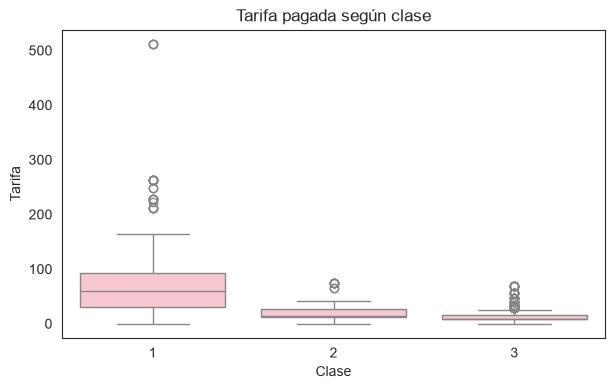

In [12]:
plt.figure(figsize=(7,4))

sns.boxplot(data=titanic, x="Pclass", y="Fare", color='pink')

plt.xlabel("Clase")
plt.ylabel("Tarifa")
plt.title("Tarifa pagada según clase")

plt.show()


### Preguntas

- La tarifa parece estar relacionada con la clase?
- Hay dispersión dentro de cada clase?
- Existen valores extremos?
- Diría que `Fare` y `Pclass` contienen exactamente la misma información?


- R: Si, la tarifa pagada se ve directamente relacionada con la clase, en donde mientras mayor la clase, mayor tarifa pagó.
- R: Hay dispersión, en la primera clase hay mayor dispersión que en las demás ya que la caja es mucho menos aplastada y tirne bigotes más largos, en cambio en la clase 2 y 3 a pesar de que si hay dispersión, es menor.
- R: Los valores extremos están dados por los cirsuos fuera de los bigotes, el más notable es el caso del outlier de la clase 1.
- R: No diría que contienen la misma información porque a pesar de que hay una relación directa entre la tarifa y la clase, no entrega un valor único de tarifa el haber estado en una clase en particular.

### Ahora usted

**1. Compare la distribución de edad entre las tres clases.**

Use un gráfico que permita comparar las distribuciones.

- Los pasajeros tienen edades similares en todas las clases?
- Qué diferencias observa?


- R: No, los pasajeros notienen edades similares ya que se puede ver que mientras mas baja sea la clase, más jóvenes son las personas, de hecho eso se puede ver también con la media en la caja de cada clase.

- R: La diferencia más notable es que la clase 2 y 3 tienen outliers y la clase 1 no contiene ninguno.

Text(0.5, 1.0, 'Distribución de edad entre las 3 clases')

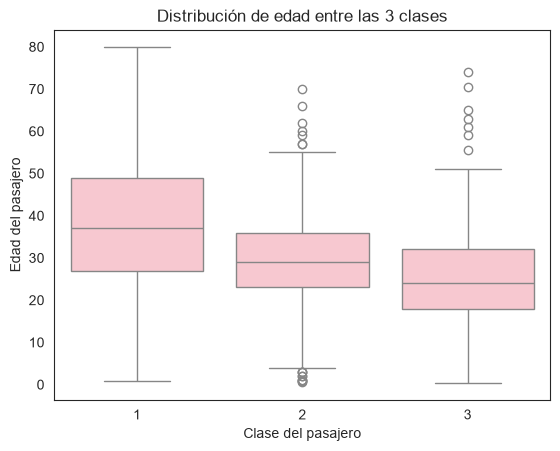

In [13]:
sns.boxplot(data=titanic, x="Pclass", y="Age", color="pink")
plt.xlabel("Clase del pasajero")
plt.ylabel("Edad del pasajero")
plt.title("Distribución de edad entre las 3 clases")

**2. Las características `SibSp` y `Parch` contienen información sobre familiares a bordo.**

Construya una nueva característica llamada `Familia`, que represente el número total de personas del grupo familiar incluyendo al propio pasajero:

\[
Familia = SibSp + Parch + 1
\]


In [14]:
# Complete el código

titanic["Familia"] = titanic["SibSp"] + titanic["Parch"] + 1


**3. Explore la nueva característica `Familia`.**

- La mayoría de los pasajeros viajaba sola o acompañada?
- Hay grupos familiares muy grandes?
- Cambiaría su interpretación si solo mirara `SibSp` o `Parch` por separado?


- R: revisando el gráfico hecho abajo, se ve que la mayoría de las personas viajaban solas.
- R: El grupo familiar más grande era de 11 personas.
- R: Respecto al analisis por grupo familiar creo que es innecesario dividirlo dependiendo de con quién viajaba.

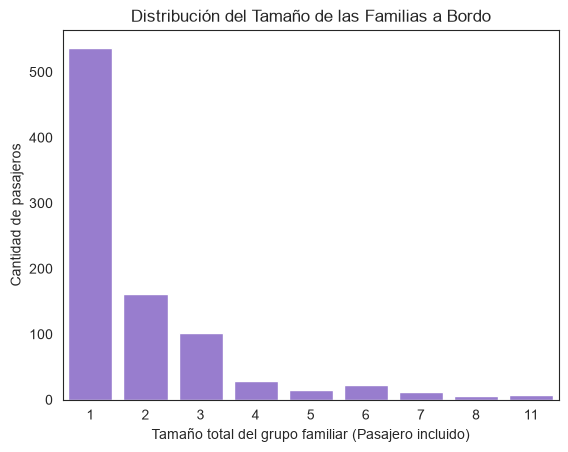

In [16]:
# Escriba aquí su código

sns.countplot(data=titanic, x="Familia", color="mediumpurple")
plt.title("Distribución del Tamaño de las Familias a Bordo")
plt.xlabel("Tamaño total del grupo familiar (Pasajero incluido)")
plt.ylabel("Cantidad de pasajeros")
plt.show()

# Parte 4: Investigar la supervivencia

## ¿Qué características estaban asociadas con la supervivencia?

Ahora incorporaremos `Survived`, la variable que queremos comprender.

Investigaremos si la supervivencia está asociada con características como:

- sexo
- clase
- edad
- tamaño del grupo familiar


### Ejemplo de gráfico: supervivencia según sexo

Como `Survived` toma valores 0 y 1, su promedio dentro de un grupo corresponde a la **fracción de pasajeros que sobrevivió**.

`seaborn.barplot` calcula por defecto la media de la variable del eje vertical.


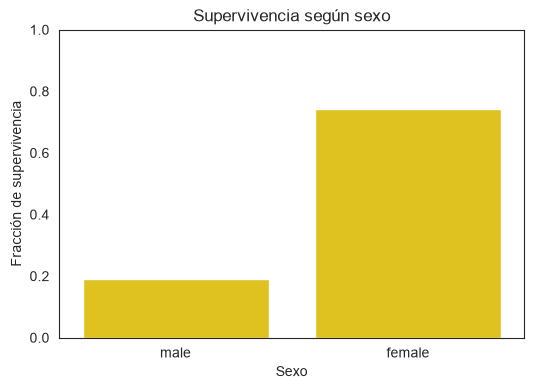

In [17]:
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Sex", y="Survived", errorbar=None, color='gold')

plt.xlabel("Sexo")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según sexo")
plt.ylim(0,1)

plt.show()


### Preguntas

- La fracción de supervivencia es similar para hombres y mujeres?
- Podemos concluir a partir de este gráfico por qué existe la diferencia?


- R1: no, la fracción de supervivencia no es similar, ya que las mujeres tienen más de el doble de fracción de supervivencia que los hombres.
- R2: No, no podemos concluir el por qué de ls diferencia, ya que no entrega nignuna información extra, sino que solo datos cuantitativos.

### Ahora usted

**1. Explore la supervivencia según `Pclass`.**

- Hay diferencias entre las tres clases?
- Existe una tendencia?


- R: Hay una clara diferencia entre las 3 clases, ya que podemos ver que mientras mas alta la clase, mayor fracción de supervivencia se evidenció. O sea, la tercera clase tuvo la fracción más baja y la primera clase truvo la fracción más alta.

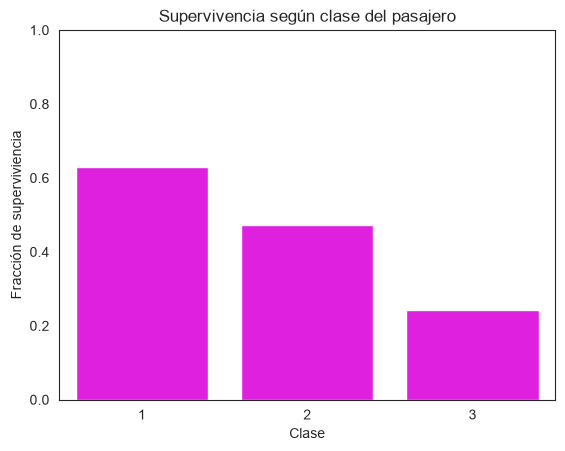

In [20]:
# Escriba aquí su código
sns.barplot(data=titanic, x="Pclass", y="Survived",errorbar=None, color="Magenta")
plt.xlabel("Clase")
plt.ylabel("Fracción de superviviencia")
plt.title("Supervivencia según clase del pasajero")
plt.ylim(0,1)
plt.show()

**2. Explore la supervivencia según edad.**

Puede comparar las distribuciones de edad de quienes sobrevivieron y quienes no sobrevivieron.

- La edad parece estar asociada con supervivencia?
- Hay algún grupo de edad que llame particularmente su atención?


- R: no se ve alguna relación marcada. Se ve que la mayor cantidad de gente que no sobrevivió estaba cerca de los 20 años, pero no mucho más.
- R: particularmente es llamativo que niños de edades pequeñas hayan tenido una supervivencia recalcable.

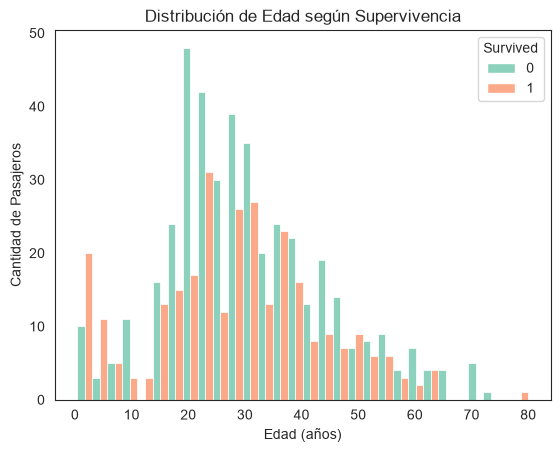

In [ ]:
# Escriba aquí su código

sns.histplot(data=titanic, x="Age", hue="Survived", multiple="dodge", bins=30, palette="Set2")
plt.title("Distribución de Edad según Supervivencia")
plt.xlabel("Edad")
plt.ylabel("Cantidad de Pasajeros")
plt.show()

**3. Explore la supervivencia según `Familia`.**

- Viajar solo parece favorable o desfavorable?
- La relación parece simple?
- Qué ocurre con los grupos familiares grandes?


- R: En la columna de pasajeros que iban solos se ve claramente que hay muchos más que no sobrevivieron que los que si, se aprecia que es casi el doble.
- R: No es una relación simple, ya que no se observa un comportamiento directo de "mientras mas grande la familia, mayor suervivencia", en este caso no se observa una tendencia clara.
- R: se observa que en los grupos familiares grandes la suopervivencia disminuye muchisimo llegando a ser nula.

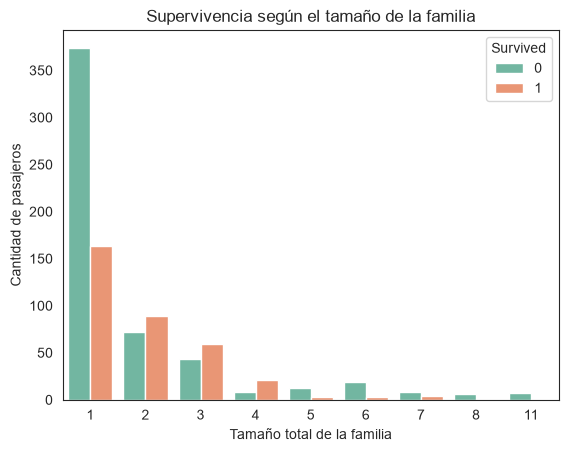

In [36]:
# Escriba aquí su código
sns.countplot(data=titanic, x="Familia", hue="Survived", palette="Set2")
plt.title("Supervivencia según el tamaño de la familia")
plt.xlabel("Tamaño total de la familia")
plt.ylabel("Cantidad de pasajeros")
plt.show()

# Parte 5: Agregar contexto

## ¿Cambia una relación cuando consideramos otra característica?

Una relación global puede esconder comportamientos diferentes dentro de la muestra.

Ya estudiamos por separado:

- `Pclass` y supervivencia
- `Sex` y supervivencia

Ahora podemos preguntar:
 **¿La relación entre clase y supervivencia es igual para hombres y mujeres?**

Esta es una forma sencilla de análisis multivariado: consideramos varias características al mismo tiempo.


### Ejemplo de gráfico: clase, sexo y supervivencia


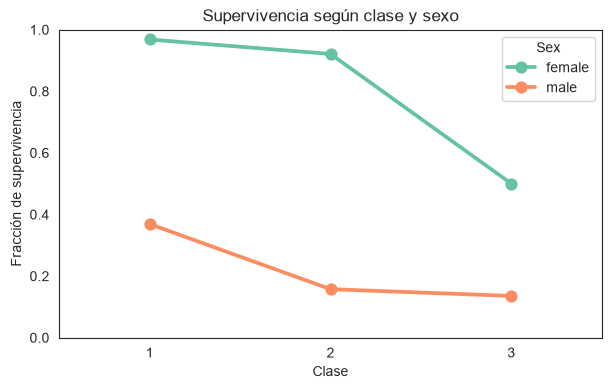

In [37]:
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Sex",
              palette="Set2",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y sexo")
plt.ylim(0,1)

plt.show()


### Preguntas sobre el ejemplo

- La relación entre clase y supervivencia es igual para hombres y mujeres?
- Qué información se perdía cuando mirábamos solamente `Pclass`?
- Qué información se perdía cuando mirábamos solamente `Sex`?
- Hay algún grupo particularmente favorecido o desfavorecido?



- R1: no, la relación no es igual, se ve claramente que las mujeres tienen una fracción mucho mayor de supervivencia que los hombres en todas lasx clases, siendo la tercera clase en ambos sexos la que menos supervivencia tuvo.

- R2: Cuando solo considerabamos la clase en relación a la suoervivencia se ignoraba por completo que la alta supervivencia de las primeras clases se debía a la contribución de las mujeres.

- R3: Cuando solo considerabamos  el sexo en relación a la supervivencia, ignorabamos impacto económico ya que si bien es cierto que las mujeres en todas las clases tuvieron mejor fracción de supervivencia, no se evidenciaba que las mujeres de tercera clase tenían casi la mitad de posibilidad de sobrevivir que las de primera clase.

- R4: se ve claramente que el grupo más favorecido es el de primera clase, en donde las mujeres en particular lideran la prioridad de evacuación al parecer ya que son las que más fracción de supervivencia tuvieron.
A su vez, se ve que la tercera clase era el grupo más desfavorecido, siendo los hombres de ese grupo a los que peor les fue con la supervivencia.

### Ahora usted

**1. Cree una característica `Persona` con tres categorías:**

- `mujer`
- `hombre`
- `niño/a`

Considere como niño/a a un pasajero menor de 16 años.


In [38]:
# Complete el código

titanic["Persona"] = titanic["Sex"].map({"female": "mujer", "male": "hombre"})
titanic.loc[titanic["Age"] < 16, "Persona"] = "niño/a"

# Revise el resultado
titanic["Persona"].value_counts()


Persona
hombre    537
mujer     271
niño/a     83
Name: count, dtype: int64

**2. Explore la supervivencia según `Persona` y `Pclass`.**

- Los niños presentan el mismo patrón que los adultos?
- La clase sigue siendo importante dentro de cada grupo?
- Qué combinación de características parece asociarse con la mayor supervivencia?


- R1: los niños presentan un patrón de supervivencia más cercano al de las mujeres, en cambio al de los hombres es totalmente diferente.
- R2: Si, la clase sigue siendo importante ya que vemos que la tercera clase sobre todo en niños y mujeres es en donde más baja la fracción de supervivencia en comparación a las otras clases.
- R3: La combinación que parece asociarse con mayor supervivencia es la de niño/a con segunda clase y mujer con primera clase.

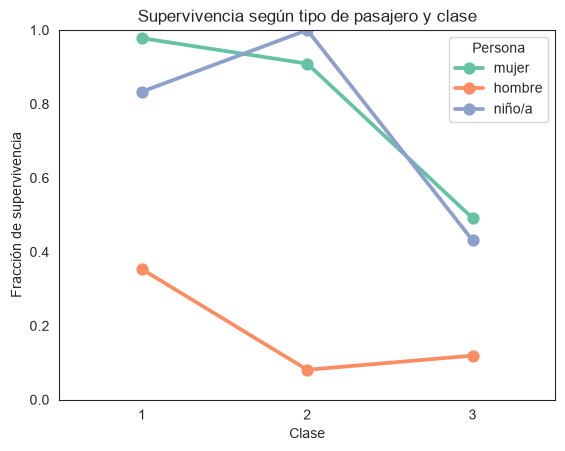

In [44]:
# Escriba aquí su código
sns.pointplot(data=titanic, x="Pclass", y="Survived", hue="Persona", errorbar=None, palette="Set2")
plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según tipo de pasajero y clase")
plt.ylim(0,1)
plt.show()

**3. Elija una relación adicional para explorar incorporando una tercera característica.**

Algunas ideas:

- edad + sexo + supervivencia;
- tamaño de familia + clase + supervivencia;
- puerto de embarque + clase + supervivencia.

No necesita crear una figura complicada. El objetivo es responder una pregunta concreta.

**Escriba primero la pregunta que quiere investigar y luego construya el gráfico.**


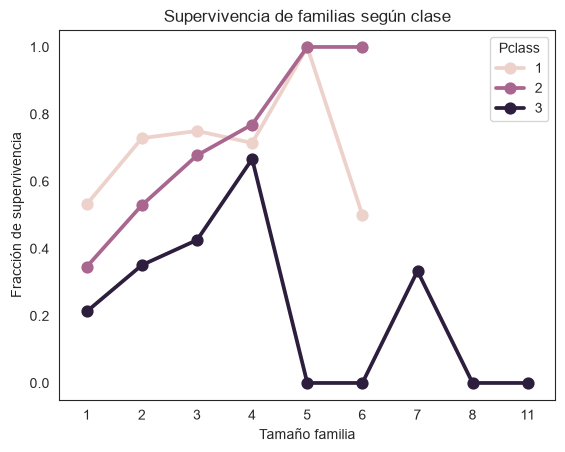

In [ ]:
# Pregunta: eligiendo tamaño de familia + clase + supervivencia, la pregunta de investigación a plantear será:
# ¿Viajar en primera clase ayudó a las familias grandes a sobrevivir, o el tamaño familiar fue una desventaja en todas las clases sociales?

# Código:

sns.pointplot(data=titanic, x="Familia", y="Survived", hue="Pclass", errorbar=None)
plt.xlabel("Tamaño familia")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia de familias según clase")

plt.show()

# Parte 6: Conclusión

## ¿Qué podemos concluir?

El EDA no termina cuando encontramos diferencias entre grupos.

Queremos distinguir entre:

### Observación
Algo que vemos directamente en los datos.

### Interpretación
Cómo describimos ese patrón.

### Hipótesis
Una explicación posible que debería ser evaluada con más información.

Por ejemplo:

> **Observación:** las mujeres presentan una mayor fracción de supervivencia que los hombres.

- **Podemos concluir, solo a partir de esta base de datos, que durante la evacuación se dio prioridad a mujeres y niños?**
- **Qué información adicional necesitaríamos para evaluar esa hipótesis?**
- **Qué otras explicaciones podrían producir el mismo patrón de supervivencia?**

## Síntesis del análisis

Revise todas las figuras construidas y responda:

### 1. Quiénes eran los pasajeros del Titanic?

Describa brevemente la muestra considerando, al menos:

- sexo
- clase
- edad
- tamaño de familia.

- Los pasajeros del titanic eran 891, de los cuales casi 600 eran hombres y alrededor de 300 eran mujeres. Los pasajeros estaban divididos en 3 clases, de las cuales la primera clase era la que pagaba mayor tarifa y la tercera clase la que pagaba la menor. Se evidenció que la edad media era cercana a los 30 años y que la mayoria viajaban solos, sin embargo existia grupos familiares de hasta 11 personas.

### 2. Qué características estaban asociadas con la supervivencia?

Considere:

- sexo
- clase
- edad
- viajar solo o acompañado.

- La característica que más relevancia tuvo a la hora de sobrevivir fue el sexo, siendo las mujeres las que más fracción de supervivencia experimentaron. De las cuales, las que viajaban en primera clase tuvieron casi un 100% de supervivencia.
A su vez, se destaca que los niños también tuvieron una alta tasa de supervivencia, de lo cual se ve ligado que al parecer viajar acompañado (en grupo familiar) pudo llegar a ser una ventaja.

### 3. Qué relaciones cambiaron al considerar varias características al mismo tiempo?

- Por ejemplo, cuando se consideraba solo fracción de supervivencia en relación a la clase, no se tenia en cuenta que el alto valor de supervivencia de la primera clase se debía a que casi el 100% de las mujeres de esa clase sobrevivieron, lo cual claramente infla el valor de supervivencia para el caso en el cual no se considera el sexo.


### 4. Encontró características que contienen información relacionada?

- Por ejemplo, al crear "Familia", se tuvo que relacionar en ella la cantidad de hermanos-conyuge "SibSp" y la cantidad de padre-hijos "Parch". Por lo que aquí se ve una relación entre características.


### 5. Qué resultado le pareció más inesperado?

Proponga una posible explicación, dejando claro qué parte corresponde a una observación y qué parte corresponde a una hipótesis.
- El resultado que me pareció más inesperado fue que las personas que viajaban solas sobrevivieron menos que las que viajaban en grupos familiares (observación). Por tanto se plantea como hipotesis que, las personas que viajaban solas eran mayoritariamente hombres (ya que dada la época, las mujeres no solían viajar solas), por lo que al darle prioridad a mujeres y niños, estos pasajeros que iban solos no tuvieron ninguna preferencia a la hora de evacuar.


# Conclusión final

## ¿Cuál es el perfil del pasajero típico que sobrevivió?

A partir de **sus propios resultados**, escriba una conclusión breve que caracterice al pasajero con mayor probabilidad de haber sobrevivido en esta muestra.

Considere, cuando corresponda:

- sexo
- edad
- clase
- tamaño del grupo familiar
- otras características que hayan resultado relevantes

Su respuesta debe estar respaldada por las figuras que construyó.


### Escriba aquí su conclusión

**El pasajero típico que sobrevivió...**

*(Complete con un párrafo breve basado en su análisis.)*


Es una mujer de primera clase, la cual viajaba con hijos, por lo tanto con un grupo familiar el cual (como se ve en el último gráfico) probablemente estaba conformado por 3,4 o 5 personas máximo. 
Vemos en el gráfico "Supervivencia según clase y sexo" que las mujeres de primera clase particularmente fueron las con mejor tasa de supervivencia a comparación por ejemplo de los hombre de primera clase, que si bien se ve que la primera clase lidera la supervivencia, es relevante la diferencia entre sexos al momento de vivir.